In [4]:
pip install matplotlib

  Using cached cycler-0.12.1-py3-none-any.whl.metadata (3.8 kB)
  Using cached kiwisolver-1.5.1-cp313-cp313-win_amd64.whl.metadata (5.2 kB)
  Using cached pillow-12.3.0-cp313-cp313-win_amd64.whl.metadata (9.3 kB)
  Using cached pyparsing-3.3.2-py3-none-any.whl.metadata (5.8 kB)
   ---------------------------------------- 0.0/9.3 MB ? eta -:--:--
   --------------- ------------------------ 3.7/9.3 MB 18.0 MB/s eta 0:00:01
   --------------------------------- ------ 7.9/9.3 MB 18.7 MB/s eta 0:00:01
   ---------------------------------------- 9.3/9.3 MB 16.5 MB/s  0:00:00
Using cached cycler-0.12.1-py3-none-any.whl (8.3 kB)
   ---------------------------------------- 0.0/2.5 MB ? eta -:--:--
   ---------------------------------------- 2.5/2.5 MB 12.2 MB/s  0:00:00
Using cached kiwisolver-1.5.1-cp313-cp313-win_amd64.whl (70 kB)
Using cached pillow-12.3.0-cp313-cp313-win_amd64.whl (7.2 MB)
Using cached pyparsing-3.3.2-py3-none-any.whl (122 kB)

   ---------------------------------------- 0/


[notice] A new release of pip is available: 25.2 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [5]:
# libraries loading 

import pandas as pd
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense,BatchNormalization,Dropout
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from matplotlib import pyplot as plt

In [6]:
# data loading 
df=pd.read_csv("Churn_Modelling.csv")
df.head()

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [9]:
# drop useless columns
df.drop(columns=["RowNumber","CustomerId","Surname","Geography"],inplace=True)

In [10]:
df.head()

,CreditScore,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,619,Female,42,2,0.00,1,1,1,101348.88,1
1,608,Female,41,1,83807.86,1,0,1,112542.58,0
2,502,Female,42,8,159660.80,3,1,0,113931.57,1
3,699,Female,39,1,0.00,2,0,0,93826.63,0
4,850,Female,43,2,125510.82,1,1,1,79084.10,0


In [11]:
# handling categorical column
df["Gender"]=df["Gender"].map({"Male":0,"Female":1})
df.head()

,CreditScore,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,619,1,42,2,0.00,1,1,1,101348.88,1
1,608,1,41,1,83807.86,1,0,1,112542.58,0
2,502,1,42,8,159660.80,3,1,0,113931.57,1
3,699,1,39,1,0.00,2,0,0,93826.63,0
4,850,1,43,2,125510.82,1,1,1,79084.10,0


In [12]:
# feature selection
x=df.drop(columns=["Exited"])
y=df["Exited"]

In [13]:
# data splitting 
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)

In [40]:
# ann architecture 
model=Sequential()

# layer 1
model.add(Dense(512,activation="sigmoid",input_dim=(9)))
model.add(Dropout(0.1))

# layer 2
model.add(Dense(256))  # by default relu 
model.add(Dropout(0.1))

# layer3 
model.add(Dense(128,activation="relu"))
model.add(Dropout(0.2))

model.add(Dense(64,activation="relu"))


# output layer
model.add(Dense(1,activation="sigmoid")) # for binary classification we use sigmoid in last layer or output layer 

# to find the trainable parametres 
model.summary()

c:\Users\INDIAN\Downloads\Artificaial_NN\venv\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_13 (Dense)                │ (None, 512)            │         5,120 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_14 (Dense)                │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_15 (Dense)                │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_16 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_17 (Dense)                │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 177,665 (694.00 KB)

 Trainable params: 177,665 (694.00 KB)

 Non-trainable params: 0 (0.00 B)

In [41]:
x.shape

(10000, 9)

In [42]:
# weights 

model.get_weights() # value of traiable parameters


[array([[-0.0664757 ,  0.03370455, -0.07914573, ...,  0.0579633 ,
         -0.02391388,  0.04058129],
        [ 0.06023221,  0.04907782, -0.00481883, ...,  0.07648799,
          0.05529432, -0.07173604],
        [-0.00243235, -0.04218733,  0.08600248, ..., -0.06056884,
         -0.01585595, -0.08760041],
        ...,
        [ 0.03553487, -0.00482316,  0.00535872, ...,  0.018089  ,
          0.04160517,  0.0769989 ],
        [ 0.09009972, -0.00684112, -0.10624285, ..., -0.0659145 ,
          0.08054858, -0.07990029],
        [ 0.05036722, -0.02823809, -0.07250962, ..., -0.09331778,
         -0.01210427, -0.08106097]], shape=(9, 512), dtype=float32),
 array([0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0.

In [43]:
# model compile 
model.compile(optimizer="adam",loss="binary_crossentropy",metrics=["accuracy"])

In [ ]:
# model fit /training
history=model.fit(x_train,y_train,batch_size=32,epochs=100,validation_split=0.2)

Epoch 1/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - accuracy: 0.7934 - loss: 0.5055 - val_accuracy: 0.7987 - val_loss: 0.4969
Epoch 2/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - accuracy: 0.7934 - loss: 0.5048 - val_accuracy: 0.7987 - val_loss: 0.4938
Epoch 3/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - accuracy: 0.7934 - loss: 0.5066 - val_accuracy: 0.7987 - val_loss: 0.4959
Epoch 4/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - accuracy: 0.7934 - loss: 0.5054 - val_accuracy: 0.7987 - val_loss: 0.4959
Epoch 5/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - accuracy: 0.7934 - loss: 0.5047 - val_accuracy: 0.7987 - val_loss: 0.4980
Epoch 6/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step - accuracy: 0.7934 - loss: 0.5077 - val_accuracy: 0.7987 - val_loss: 0.5050
Epoch 7/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - accuracy: 0.7934 - loss: 0.5075 - val_accuracy: 0.7987 - val_loss: 0.4963
Epoch 8/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - accuracy: 0.7934 - loss: 0.5048 - val_

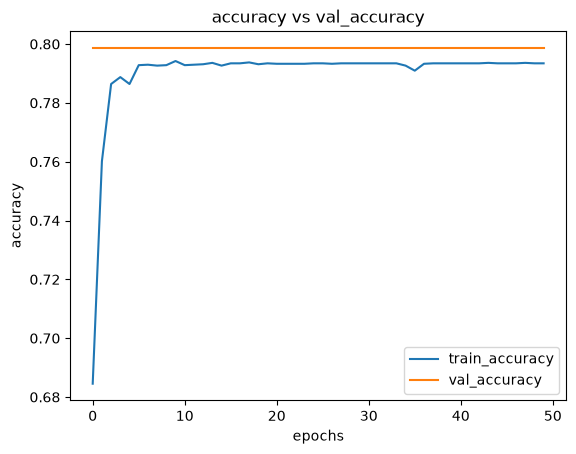

In [38]:
# accuracy 
plt.plot(history.history["accuracy"],label="train_accuracy")
plt.plot(history.history["val_accuracy"],label="val_accuracy")
plt.title("accuracy vs val_accuracy")
plt.xlabel("epochs")
plt.ylabel("accuracy")
plt.legend()
plt.show()

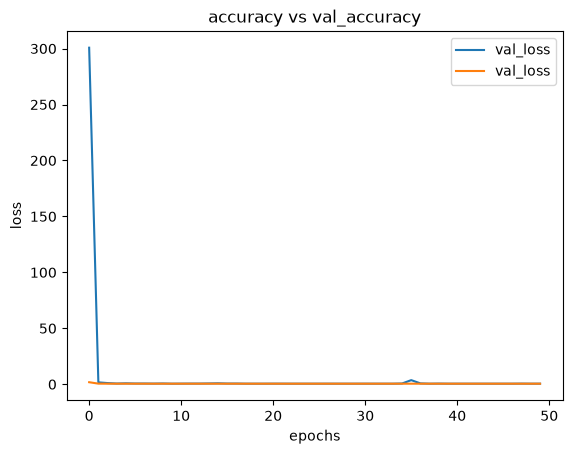

In [39]:
# loss
plt.plot(history.history["loss"],label="val_loss")
plt.plot(history.history["val_loss"],label="val_loss")
plt.title("accuracy vs val_accuracy")
plt.xlabel("epochs")
plt.ylabel("loss")
plt.legend()
plt.show()

In [ ]:
# howw to prevent model from overfiiting
# dropout
# batch normalization
# weight initialization
# regularization 
# epochs increase
# layers add
# nodes increase 
# activation change
# optimizers change 
# data augmenstation
# keras tuning